# Mercury6 Project

## Initialize

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from astropy.time import Time
from astroquery.jplhorizons import Horizons

In [137]:
AU_TO_KM = 149597870.7
EARTH_RADIUS_KM = 6371.0
DAYS_PER_JULIAN_YEAR = 365.25

OBJECT = {
    'SUN': {
        'id': '10',
        'name': 'Sun',
        'color': 'darkorange'
    },
    'EARTH': {
        'id': '3',
        'name': 'Earth',
        'color': 'dodgerblue'
    },
    'APOPHIS': {
        'id': '99942',
        'name': '99942 Apophis',
        'color': 'indianred'
    },
    'KAMOO': {
        'id': '469219',
        'name': "469219 Kamo'oalewa",
        'color': 'mediumslateblue'
    },
    'FW13': {
        'id': '2023 FW13',
        'name': '2023 FW13',
        'color': 'lightseagreen'
    }
}

# 6 Year Long-term Simulation: 2461143.5 to 2463335.5
EPOCH_START_LONG_JD = 2461143.5

# Apophis Encounter: 2462239.5 to 2462241.5
EPOCH_START_ENCOUNTER_JD = 2462239.5

In [138]:
# Load data
col = ['time', 'long', 'x', 'y', 'z']

# 6 Year Long-term Simulation: 2461143.5 to 2463335.5
r_e = pd.read_csv('EARTH.aei', sep='\s+', skiprows=4, names=col)
r_k = pd.read_csv('KAMOOALEWA.aei', sep='\s+', skiprows=4, names=col)
r_f = pd.read_csv('2023FW13.aei', sep='\s+', skiprows=4, names=col)
r_a = pd.read_csv('APOPHIS.aei', sep='\s+', skiprows=4, names=col)

#Apophis Encounter: 2462239.5 to 2462241.5
start_jd_enc = 2462239.5
r_a_enc = pd.read_csv('../Apophis_encounter/APOPHIS.aei', sep='\s+', skiprows=4, names=col)
r_e_enc = pd.read_csv('../Apophis_encounter/EARTH.aei', sep='\s+', skiprows=4, names=col)

In [139]:
# Horizons Data
duration_years = 1
stop_jd = EPOCH_START_LONG_JD + (duration_years * DAYS_PER_JULIAN_YEAR)

start_iso = Time(EPOCH_START_LONG_JD, format='jd').to_value('iso', subfmt='date')
stop_iso = Time(stop_jd, format='jd').to_value('iso', subfmt='date')

epochs = {
    'start': start_iso,
    'stop': stop_iso,
    'step': '10d'
}

obj_k_hor = Horizons(id=OBJECT['KAMOO']['id'], location='@sun', epochs=epochs)
vec_k_hor = obj_k_hor.vectors()

obj_f_hor = Horizons(id=OBJECT['FW13']['id'], location='@sun', epochs=epochs)
vec_f_hor = obj_f_hor.vectors()

obj_e_hor = Horizons(id=OBJECT['EARTH']['id'], location='@sun', epochs=epochs)
vec_e_hor = obj_e_hor.vectors()

In [140]:
def get_rotation_coords(df_target, df_earth):
    theta = np.arctan2(df_earth['y'], df_earth['x'])
    
    x_rot = df_target['x'] * np.cos(theta) + df_target['y'] * np.sin(theta) - (df_earth['x'] * np.cos(theta) + df_earth['y'] * np.sin(theta))
    y_rot = -df_target['x'] * np.sin(theta) + df_target['y'] * np.cos(theta) - (-df_earth['x'] * np.sin(theta) + df_earth['y'] * np.cos(theta))
    z_rot = df_target['z'] - df_earth['z']
    
    return x_rot, y_rot, z_rot

## ICRF

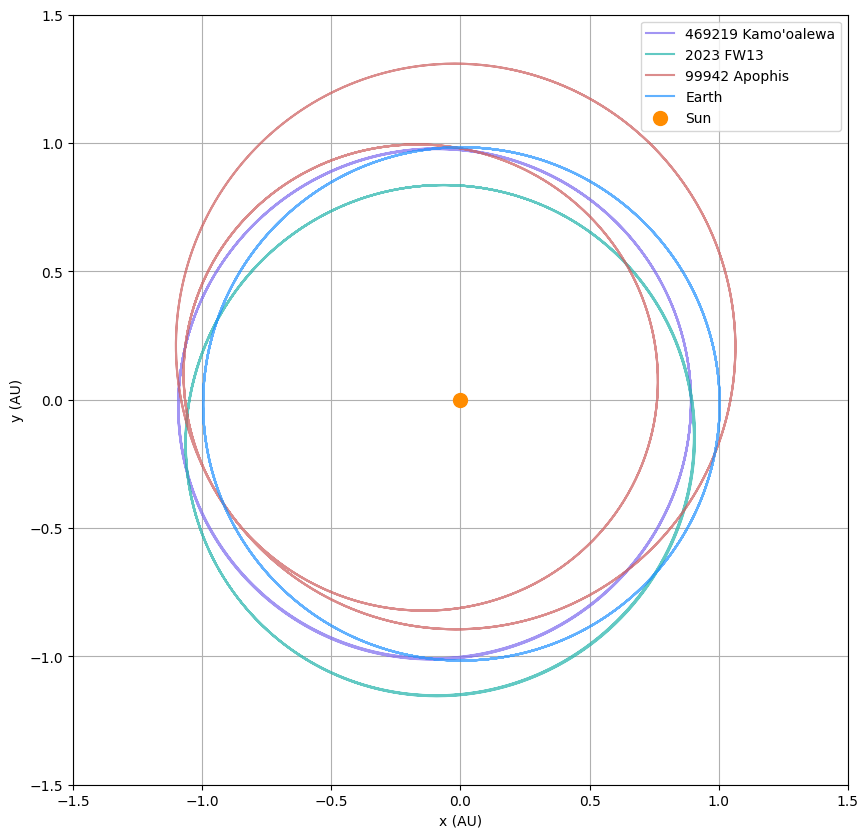

In [141]:
# ICRF Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(r_k['x'], r_k['y'], label=OBJECT['KAMOO']['name'], color=OBJECT['KAMOO']['color'], alpha=0.7, zorder=2)
ax.plot(r_f['x'], r_f['y'], label=OBJECT['FW13']['name'], color=OBJECT['FW13']['color'], alpha=0.7, zorder=2)
ax.plot(r_a['x'], r_a['y'], label=OBJECT['APOPHIS']['name'], color=OBJECT['APOPHIS']['color'], alpha=0.7, zorder=2)
ax.plot(r_e['x'], r_e['y'], label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], alpha=0.7, zorder=2)
ax.scatter(0, 0, label=OBJECT['SUN']['name'], color=OBJECT['SUN']['color'], s=100, zorder=2)

ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.show()

## Earth-centric Rotational Coordinates

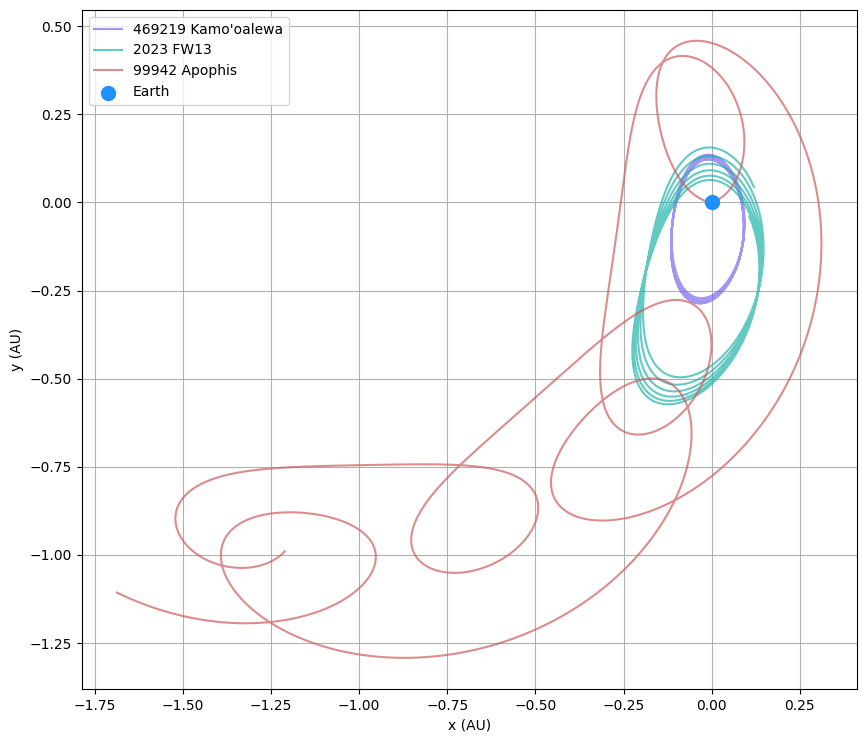

In [142]:
# Rotational Coordinates
x_rot_k, y_rot_k, z_rot_k = get_rotation_coords(r_k, r_e)
x_rot_f, y_rot_f, z_rot_f = get_rotation_coords(r_f, r_e)
x_rot_a, y_rot_a, z_rot_a = get_rotation_coords(r_a, r_e)

# Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(x_rot_k, y_rot_k, label=OBJECT['KAMOO']['name'], color=OBJECT['KAMOO']['color'], alpha=0.7, zorder=2)
ax.plot(x_rot_f, y_rot_f, label=OBJECT['FW13']['name'], color=OBJECT['FW13']['color'], alpha=0.7, zorder=2)
ax.plot(x_rot_a, y_rot_a, label=OBJECT['APOPHIS']['name'], color=OBJECT['APOPHIS']['color'], alpha=0.7, zorder=2)
ax.scatter(0, 0, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], s=100, zorder=2)

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)

plt.show()

## Apophis Encounter

/home/saika/miniconda3/envs/astro/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


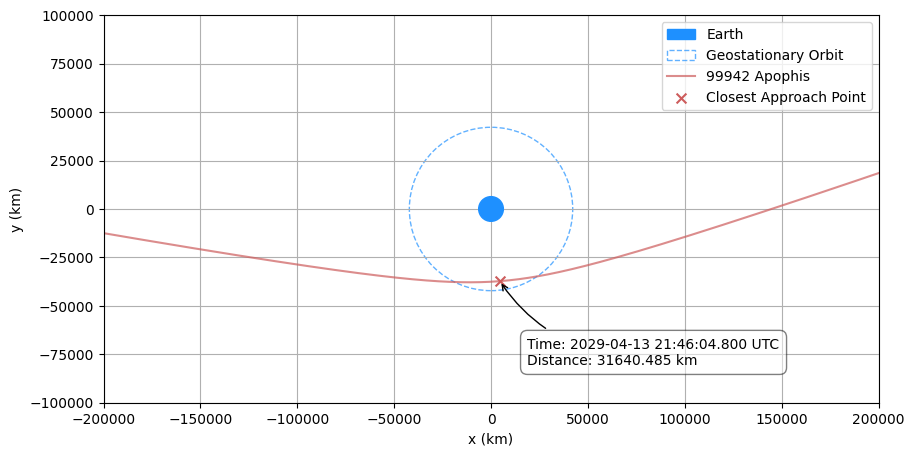

In [143]:
# Rotational Coordinates
x_rot_au, y_rot_au, z_rot_au = get_rotation_coords(r_a_enc, r_e_enc)

x_rot_enc = x_rot_au * AU_TO_KM
y_rot_enc = y_rot_au * AU_TO_KM
z_rot_enc = z_rot_au * AU_TO_KM

# Closest Approach
enc_dist = np.sqrt(x_rot_enc**2 + y_rot_enc**2 + z_rot_enc**2)
min_idx = enc_dist.idxmin()
closest_x, closest_y, closest_z = x_rot_enc[min_idx], y_rot_enc[min_idx], z_rot_enc[min_idx]

min_dist = enc_dist[min_idx] - EARTH_RADIUS_KM
min_time = r_a_enc['time'][min_idx] + EPOCH_START_ENCOUNTER_JD
min_time_iso = Time(min_time, format='jd').iso

# Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(10, 10))

earth = plt.Circle((0, 0), EARTH_RADIUS_KM, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], zorder=2)
ax.add_patch(earth)

geo = plt.Circle((0, 0), 42164, label='Geostationary Orbit', color=OBJECT['EARTH']['color'], fill=False, linestyle='--', alpha=0.7, zorder=1)
ax.add_patch(geo)

ax.plot(x_rot_enc, y_rot_enc, label=OBJECT['APOPHIS']['name'], color=OBJECT['APOPHIS']['color'], alpha=0.7, zorder=2)
ax.scatter(closest_x, closest_y, label='Closest Approach Point', color=OBJECT['APOPHIS']['color'], marker='x', s=50, zorder=3)

label_text = f"Time: {min_time_iso} UTC\nDistance: {min_dist:.3f} km"
ax.annotate(label_text,
            xy=(closest_x, closest_y),
            xytext=(20, -60),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color='black'),
            bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.5'),
            zorder=4)

ax.set_aspect('equal')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.legend()
ax.grid(True)

ax.set_xlim(-200000, 200000)
ax.set_ylim(-100000, 100000)

plt.show()

## Horizons Data Comparison

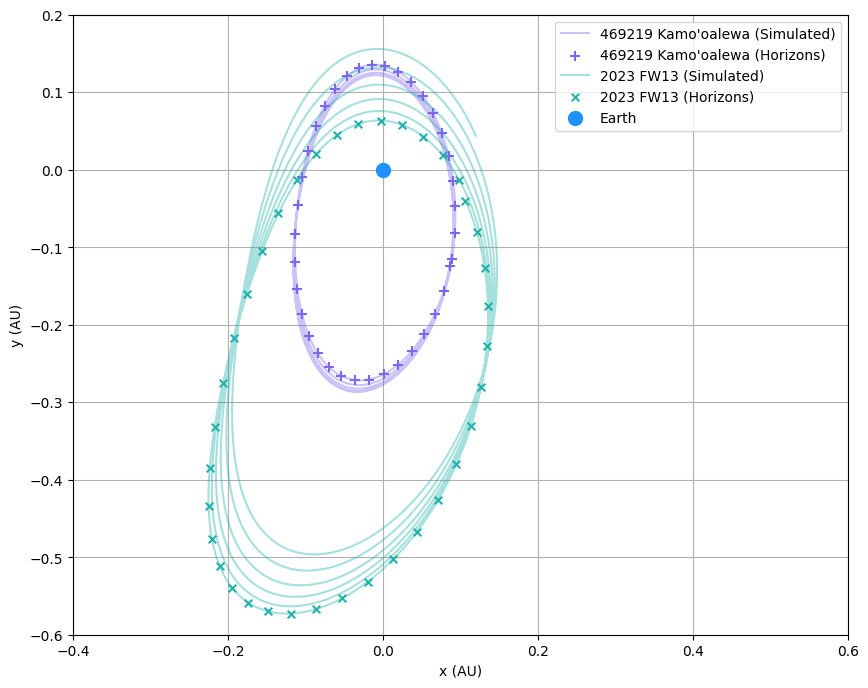

In [144]:
# Rotation Coordinates
x_rot_k_hor, y_rot_k_hor, z_rot_k_hor = get_rotation_coords(vec_k_hor, vec_e_hor)
x_rot_f_hor, y_rot_f_hor, z_rot_f_hor = get_rotation_coords(vec_f_hor, vec_e_hor)

# Horizons Rotational Coordinates Plotting
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(x_rot_k, y_rot_k, label=f"{OBJECT['KAMOO']['name']} (Simulated)", color=OBJECT['KAMOO']['color'], alpha=0.4, zorder=2)
ax.scatter(x_rot_k_hor, y_rot_k_hor, label=f"{OBJECT['KAMOO']['name']} (Horizons)", color=OBJECT['KAMOO']['color'], marker='+', s=50, zorder=3)

ax.plot(x_rot_f, y_rot_f, label=f"{OBJECT['FW13']['name']} (Simulated)", color=OBJECT['FW13']['color'], alpha=0.4, zorder=2)
ax.scatter(x_rot_f_hor, y_rot_f_hor, label=f"{OBJECT['FW13']['name']} (Horizons)", color=OBJECT['FW13']['color'], marker='x', s=30, zorder=3)

ax.scatter(0, 0, label=OBJECT['EARTH']['name'], color=OBJECT['EARTH']['color'], s=100, zorder=3)

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.legend()
ax.grid(True)

ax.set_xlim(-0.4, 0.6)
ax.set_ylim(-0.6, 0.2)

plt.show()